In [ ]:
import pandas as pd

caminho_arquivo = "dados_concreto - Sheet1.csv"
df = pd.read_csv(caminho_arquivo)

In [ ]:
print(df.head())

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate    Age  Concrete compressive strength  \
0            1040.0           676.0   28.0                          79.99   
1            1055.0           676.0   28.0                          61.89   
2             932.0           594.0  270.0                          40.27   
3             932.0           594.0  365.0                          41.05   
4             978.4           825.5  360.0                          44.30   

  Strength Category  
0              Alto  
1              Alto  
2             Baixa  
3             Baixa  
4             Baixa  


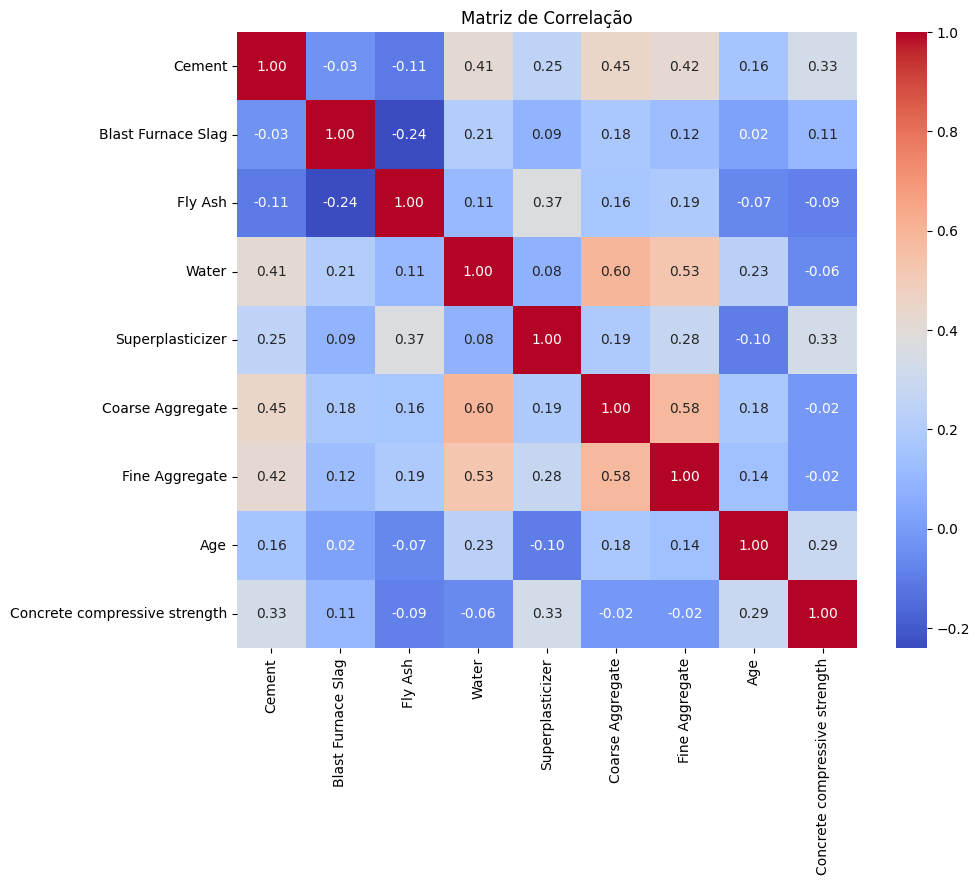

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

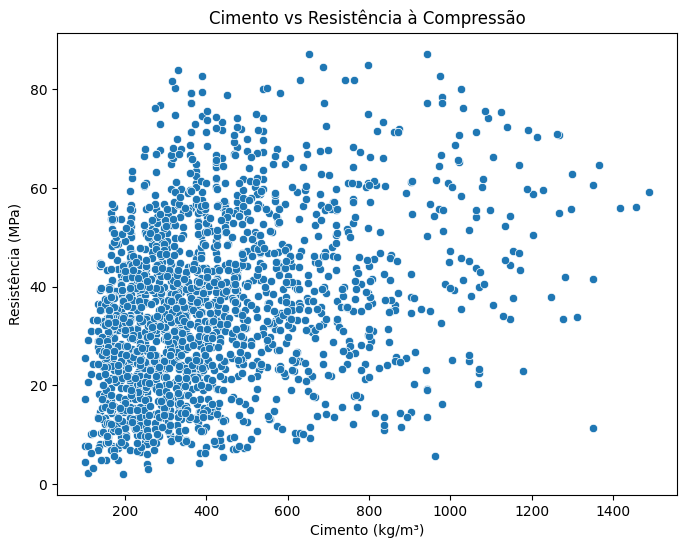

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Cement', y='Concrete compressive strength')
plt.title('Cimento vs Resistência à Compressão')
plt.xlabel('Cimento (kg/m³)')
plt.ylabel('Resistência (MPa)')
plt.show()

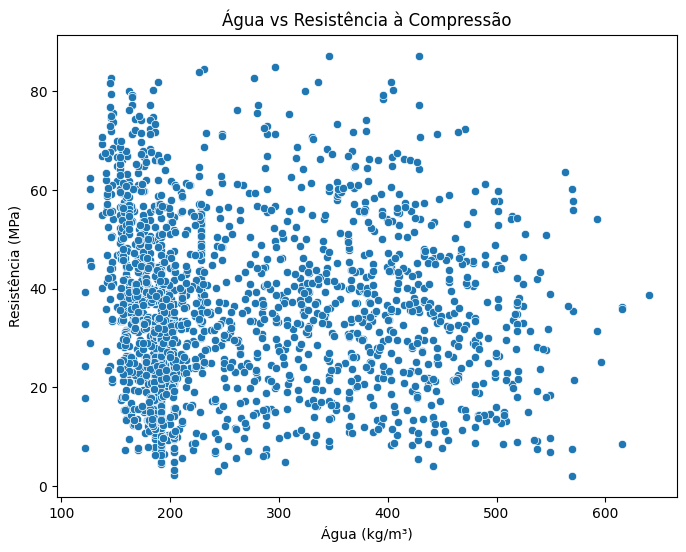

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Water', y='Concrete compressive strength')
plt.title('Água vs Resistência à Compressão')
plt.xlabel('Água (kg/m³)')
plt.ylabel('Resistência (MPa)')
plt.show()

<ipython-input-11-c784846b742d>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_strength_by_category.values, y=mean_strength_by_category.index, palette="viridis")


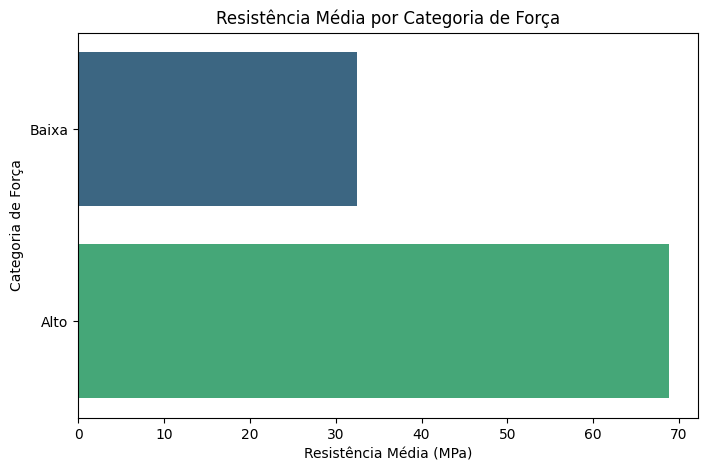

In [ ]:
mean_strength_by_category = df.groupby('Strength Category')['Concrete compressive strength'].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=mean_strength_by_category.values, y=mean_strength_by_category.index, palette="viridis")
plt.title('Resistência Média por Categoria de Força')
plt.xlabel('Resistência Média (MPa)')
plt.ylabel('Categoria de Força')
plt.show()

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    9
Strength Category                0
dtype: int64


In [ ]:
df_encoded = pd.get_dummies(df, columns=['Strength Category'], drop_first=True)

In [ ]:
missing_after_encoding = df_encoded.isnull().sum()
print(missing_after_encoding)

Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    9
Strength Category_Baixa          0
dtype: int64


In [ ]:
df_encoded = df_encoded.dropna()

In [ ]:
X = df_encoded.drop(columns=['Concrete compressive strength'])
y = df_encoded['Concrete compressive strength']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

print({
    "Random Forest": {"R²": rf_r2, "MAE": rf_mae},
    "Regressão Linear": {"R²": lr_r2, "MAE": lr_mae}
})

{'Random Forest': {'R²': 0.8176825520328866, 'MAE': 5.008484678217823}, 'Regressão Linear': {'R²': 0.5193022302862832, 'MAE': 9.344575101697886}}


In [ ]:
#O modelo escolhido Foi o Random Forest,
#pois em comparativo com a regressão linear,
#ele obteve valores com maior poder explicativo *R2 mais alto*
#Obtendo uma taxa explicativa de 81% da variância.
#E uma MAE menor, *5*, sendo aceitável em relação ao objetivo prático.

<ipython-input-23-31aa51b82336>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_sorted, y=feature_importances_sorted.index, palette="viridis")


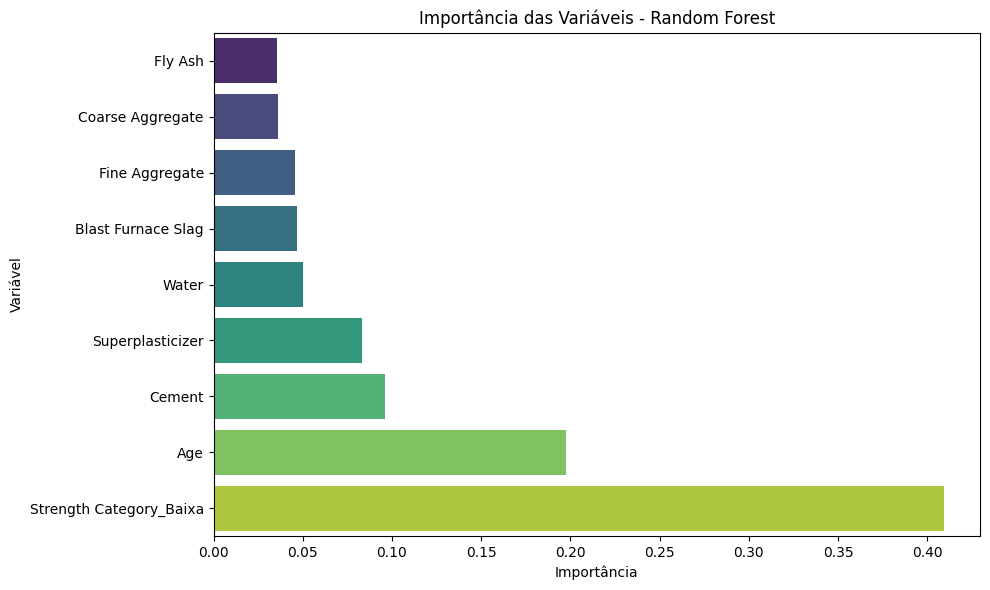

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances_sorted = feature_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_sorted, y=feature_importances_sorted.index, palette="viridis")
plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

In [ ]:
nova_amostra = {
    'Cement': 550,
    'Blast Furnace Slag': 150,
    'Fly Ash': 0,
    'Water': 180,
    'Superplasticizer': 2.5,
    'Coarse Aggregate': 1000,
    'Fine Aggregate': 700,
    'Age': 25,
    'Strength Category_Baixa': 0
}

nova_amostra_df = pd.DataFrame([nova_amostra])[X.columns]

resistencia_prevista = rf_model.predict(nova_amostra_df)[0]
print(f"Resistência prevista do concreto: {resistencia_prevista:.2f} MPa")

Resistência prevista do concreto: 72.12 MPa
